## Fase 6A: Pré-processamento dos Dados para o Modelo de IA

Neste notebook, vamos realizar o pré-processamento dos dados coletados na Sprint 1 para prepará-los para o desenvolvimento do modelo de IA para previsão de produtividade agrícola.

In [13]:
# Configuração do ambiente
import sys
sys.path.append('../../')
import setup_notebook
setup_notebook.setup_environment()

%matplotlib inline

Installing scikit-learn...
scikit-learn installed successfully.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: pip install --upgrade pip


Environment setup complete.
Project root: /Users/gab/Documents/CodePlay/@fiap
Assets directory: /Users/gab/Documents/CodePlay/@fiap/assets


## Introdução

Na Sprint 1, coletamos dados de NDVI/EVI da plataforma SATVeg e dados de produtividade agrícola de diversas fontes. Agora, vamos organizar e pré-processar esses dados para que possam ser utilizados no desenvolvimento do modelo de IA para previsão de produtividade agrícola.

Neste notebook, vamos focar nas seguintes tarefas:

1. Carregamento dos dados de NDVI/EVI e produtividade agrícola
2. Limpeza e tratamento de valores ausentes
3. Normalização e padronização dos dados
4. Análise exploratória para identificar padrões e sazonalidades
5. Preparação dos dados para o modelo de IA

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# Configurar o estilo dos gráficos
plt.style.use('fivethirtyeight')
sns.set(style="whitegrid")

## 1. Carregamento dos Dados

Vamos carregar os dados de NDVI/EVI e produtividade agrícola que coletamos na Sprint 1.

In [15]:
# Carregar os dados de NDVI/EVI
df_ndvi_nf_monthly = pd.read_csv('../../assets/ndvi_mensal_nova_friburgo.csv')
df_ndvi_t_monthly = pd.read_csv('../../assets/ndvi_mensal_teresopolis.csv')
df_ndvi_nf_annual = pd.read_csv('../../assets/ndvi_anual_nova_friburgo.csv')
df_ndvi_t_annual = pd.read_csv('../../assets/ndvi_anual_teresopolis.csv')

# Carregar os dados de produtividade agrícola
df_prod_combinados = pd.read_csv('../../assets/dados_produtividade_combinados.csv')
df_prod_temporaria = pd.read_csv('../../assets/dados_produtividade_temporaria.csv')
df_prod_permanente = pd.read_csv('../../assets/dados_produtividade_permanente.csv')

# Exibir informações sobre os dataframes
print("Informações sobre os dados de NDVI/EVI mensais de Nova Friburgo:")
print(f"Número de registros: {df_ndvi_nf_monthly.shape[0]}")
print(f"Número de colunas: {df_ndvi_nf_monthly.shape[1]}")
print(f"Colunas: {', '.join(df_ndvi_nf_monthly.columns)}")
print("\nInformações sobre os dados de produtividade combinados:")
print(f"Número de registros: {df_prod_combinados.shape[0]}")
print(f"Número de colunas: {df_prod_combinados.shape[1]}")
print(f"Colunas: {', '.join(df_prod_combinados.columns)}")

Informações sobre os dados de NDVI/EVI mensais de Nova Friburgo:
Número de registros: 302
Número de colunas: 10
Colunas: Ano, Mês, EVI_mean, EVI_min, EVI_max, EVI_std, SG_mean, SG_min, SG_max, SG_std

Informações sobre os dados de produtividade combinados:
Número de registros: 60
Número de colunas: 8
Colunas: Município, Ano, Cultura, Área Plantada (ha), Produção (t), Produtividade (t/ha), Valor da Produção (mil R$), Tipo de Lavoura


## 2. Limpeza e Tratamento de Valores Ausentes

Vamos verificar se existem valores ausentes nos dados e tratá-los adequadamente.

In [16]:
# Verificar valores ausentes nos dados de NDVI/EVI
print("Valores ausentes nos dados de NDVI/EVI mensais de Nova Friburgo:")
print(df_ndvi_nf_monthly.isnull().sum())
print("\nValores ausentes nos dados de NDVI/EVI mensais de Teresópolis:")
print(df_ndvi_t_monthly.isnull().sum())

# Verificar valores ausentes nos dados de produtividade
print("\nValores ausentes nos dados de produtividade combinados:")
print(df_prod_combinados.isnull().sum())

Valores ausentes nos dados de NDVI/EVI mensais de Nova Friburgo:
Ano          0
Mês          0
EVI_mean     0
EVI_min      0
EVI_max      0
EVI_std     26
SG_mean      0
SG_min       0
SG_max       0
SG_std      26
dtype: int64

Valores ausentes nos dados de NDVI/EVI mensais de Teresópolis:
Ano          0
Mês          0
EVI_mean     0
EVI_min      0
EVI_max      0
EVI_std     26
SG_mean      0
SG_min       0
SG_max       0
SG_std      26
dtype: int64

Valores ausentes nos dados de produtividade combinados:
Município                     0
Ano                           0
Cultura                       0
Área Plantada (ha)            0
Produção (t)                  0
Produtividade (t/ha)          0
Valor da Produção (mil R$)    0
Tipo de Lavoura               0
dtype: int64


In [17]:
# Tratar valores ausentes nos dados de NDVI/EVI
# Vamos usar o SimpleImputer para preencher os valores ausentes com a média
imputer = SimpleImputer(strategy='mean')

# Aplicar o imputer aos dados de NDVI/EVI mensais de Nova Friburgo
df_ndvi_nf_monthly_numeric = df_ndvi_nf_monthly.select_dtypes(include=[np.number])
df_ndvi_nf_monthly_numeric_imputed = pd.DataFrame(imputer.fit_transform(df_ndvi_nf_monthly_numeric), 
                                                 columns=df_ndvi_nf_monthly_numeric.columns)
df_ndvi_nf_monthly_non_numeric = df_ndvi_nf_monthly.select_dtypes(exclude=[np.number])
df_ndvi_nf_monthly_imputed = pd.concat([df_ndvi_nf_monthly_non_numeric.reset_index(drop=True), 
                                       df_ndvi_nf_monthly_numeric_imputed.reset_index(drop=True)], axis=1)

# Aplicar o imputer aos dados de NDVI/EVI mensais de Teresópolis
df_ndvi_t_monthly_numeric = df_ndvi_t_monthly.select_dtypes(include=[np.number])
df_ndvi_t_monthly_numeric_imputed = pd.DataFrame(imputer.fit_transform(df_ndvi_t_monthly_numeric), 
                                               columns=df_ndvi_t_monthly_numeric.columns)
df_ndvi_t_monthly_non_numeric = df_ndvi_t_monthly.select_dtypes(exclude=[np.number])
df_ndvi_t_monthly_imputed = pd.concat([df_ndvi_t_monthly_non_numeric.reset_index(drop=True), 
                                     df_ndvi_t_monthly_numeric_imputed.reset_index(drop=True)], axis=1)

# Verificar se ainda existem valores ausentes
print("Valores ausentes nos dados de NDVI/EVI mensais de Nova Friburgo após tratamento:")
print(df_ndvi_nf_monthly_imputed.isnull().sum())
print("\nValores ausentes nos dados de NDVI/EVI mensais de Teresópolis após tratamento:")
print(df_ndvi_t_monthly_imputed.isnull().sum())

Valores ausentes nos dados de NDVI/EVI mensais de Nova Friburgo após tratamento:
Ano         0
Mês         0
EVI_mean    0
EVI_min     0
EVI_max     0
EVI_std     0
SG_mean     0
SG_min      0
SG_max      0
SG_std      0
dtype: int64

Valores ausentes nos dados de NDVI/EVI mensais de Teresópolis após tratamento:
Ano         0
Mês         0
EVI_mean    0
EVI_min     0
EVI_max     0
EVI_std     0
SG_mean     0
SG_min      0
SG_max      0
SG_std      0
dtype: int64


## 3. Normalização e Padronização dos Dados

Vamos normalizar e padronizar os dados para facilitar o treinamento do modelo de IA.

In [18]:
# Normalizar os dados de NDVI/EVI
scaler = MinMaxScaler()

# Aplicar o scaler aos dados de NDVI/EVI mensais de Nova Friburgo
df_ndvi_nf_monthly_numeric_scaled = pd.DataFrame(scaler.fit_transform(df_ndvi_nf_monthly_imputed.select_dtypes(include=[np.number])), 
                                               columns=df_ndvi_nf_monthly_imputed.select_dtypes(include=[np.number]).columns)
df_ndvi_nf_monthly_non_numeric = df_ndvi_nf_monthly_imputed.select_dtypes(exclude=[np.number])
df_ndvi_nf_monthly_scaled = pd.concat([df_ndvi_nf_monthly_non_numeric.reset_index(drop=True), 
                                     df_ndvi_nf_monthly_numeric_scaled.reset_index(drop=True)], axis=1)

# Aplicar o scaler aos dados de NDVI/EVI mensais de Teresópolis
df_ndvi_t_monthly_numeric_scaled = pd.DataFrame(scaler.fit_transform(df_ndvi_t_monthly_imputed.select_dtypes(include=[np.number])), 
                                             columns=df_ndvi_t_monthly_imputed.select_dtypes(include=[np.number]).columns)
df_ndvi_t_monthly_non_numeric = df_ndvi_t_monthly_imputed.select_dtypes(exclude=[np.number])
df_ndvi_t_monthly_scaled = pd.concat([df_ndvi_t_monthly_non_numeric.reset_index(drop=True), 
                                   df_ndvi_t_monthly_numeric_scaled.reset_index(drop=True)], axis=1)

# Exibir estatísticas descritivas dos dados normalizados
print("Estatísticas descritivas dos dados de NDVI/EVI mensais de Nova Friburgo após normalização:")
print(df_ndvi_nf_monthly_scaled.describe())
print("\nEstatísticas descritivas dos dados de NDVI/EVI mensais de Teresópolis após normalização:")
print(df_ndvi_t_monthly_scaled.describe())

Estatísticas descritivas dos dados de NDVI/EVI mensais de Nova Friburgo após normalização:
              Ano         Mês    EVI_mean     EVI_min     EVI_max     EVI_std  \
count  302.000000  302.000000  302.000000  302.000000  302.000000  302.000000   
mean     0.486755    0.497592    0.520072    0.660492    0.480989    0.122118   
std      0.291217    0.314713    0.126762    0.106386    0.133743    0.129953   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      0.240000    0.181818    0.464251    0.631377    0.406775    0.031855   
50%      0.480000    0.454545    0.529364    0.680859    0.476198    0.083063   
75%      0.720000    0.727273    0.590281    0.719559    0.556005    0.151340   
max      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   

          SG_mean      SG_min      SG_max      SG_std  
count  302.000000  302.000000  302.000000  302.000000  
mean     0.567403    0.534332    0.576441    0.238111  
std      0.

## 4. Análise Exploratória para Identificar Padrões e Sazonalidades

Vamos realizar uma análise exploratória dos dados para identificar padrões e sazonalidades que possam ser úteis para o modelo de IA.

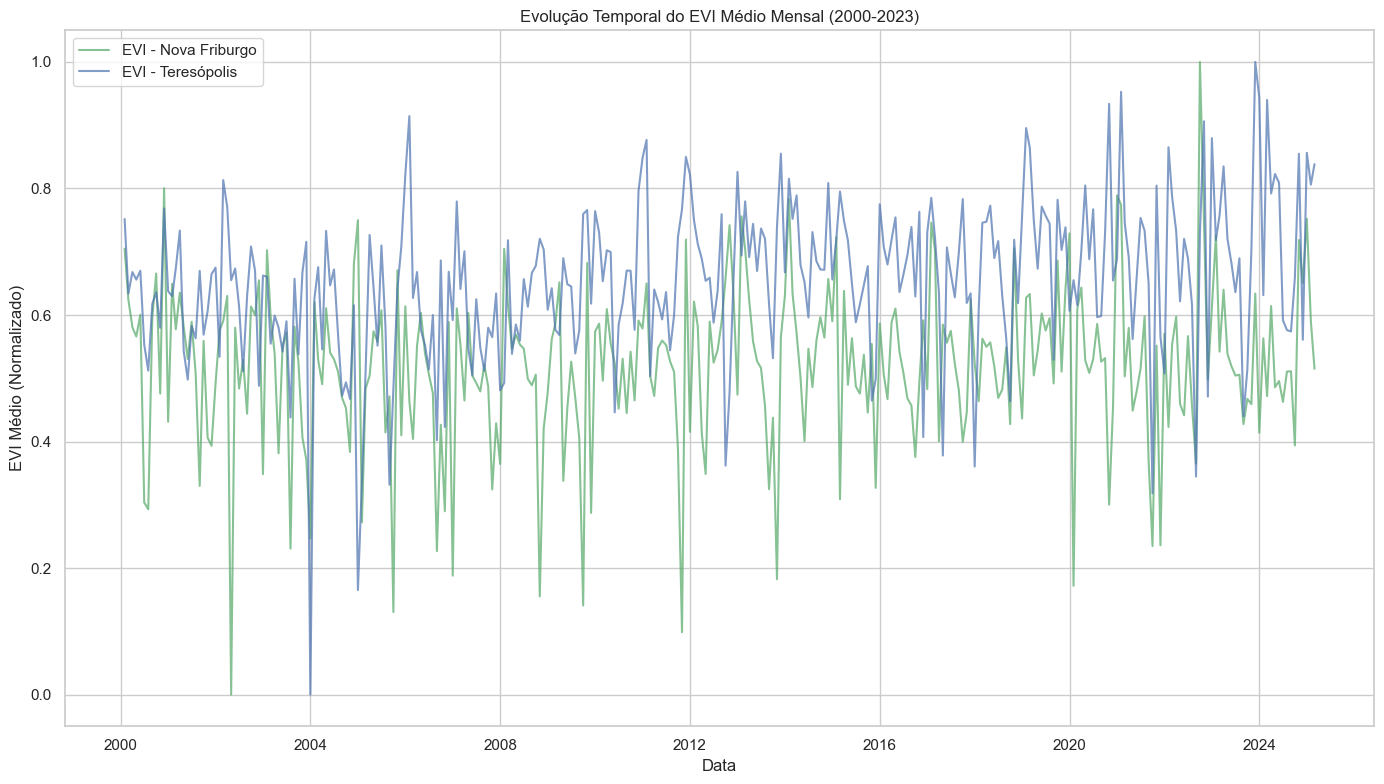

In [19]:
# Criar um dataframe com a data completa para visualização
# Usar os valores originais de Ano e Mês para criar a coluna de data
df_ndvi_nf_monthly_scaled['Data'] = pd.to_datetime(df_ndvi_nf_monthly['Ano'].astype(str) + '-' + 
                                                df_ndvi_nf_monthly['Mês'].astype(str) + '-01')
df_ndvi_t_monthly_scaled['Data'] = pd.to_datetime(df_ndvi_t_monthly['Ano'].astype(str) + '-' + 
                                              df_ndvi_t_monthly['Mês'].astype(str) + '-01')

# Criar um gráfico de linhas para a evolução temporal do EVI médio mensal
plt.figure(figsize=(14, 8))

# Plotar o EVI médio mensal para Nova Friburgo
plt.plot(df_ndvi_nf_monthly_scaled['Data'], df_ndvi_nf_monthly_scaled['EVI_mean'], 'g-', 
         alpha=0.7, label='EVI - Nova Friburgo')

# Plotar o EVI médio mensal para Teresópolis
plt.plot(df_ndvi_t_monthly_scaled['Data'], df_ndvi_t_monthly_scaled['EVI_mean'], 'b-', 
         alpha=0.7, label='EVI - Teresópolis')

plt.title('Evolução Temporal do EVI Médio Mensal (2000-2023)')
plt.xlabel('Data')
plt.ylabel('EVI Médio (Normalizado)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

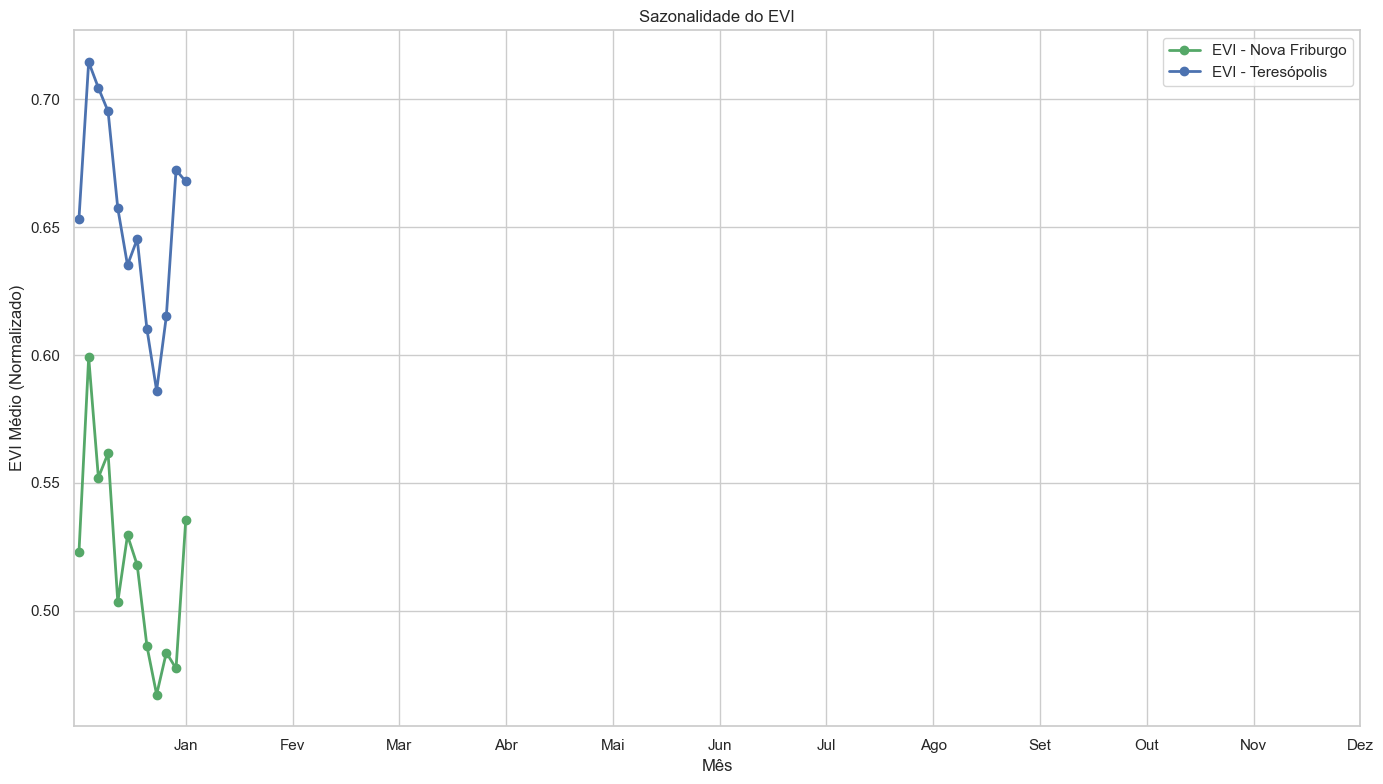

In [20]:
# Calcular a média mensal do EVI para cada município
evi_monthly_nf = df_ndvi_nf_monthly_scaled.groupby('Mês')['EVI_mean'].mean()
evi_monthly_t = df_ndvi_t_monthly_scaled.groupby('Mês')['EVI_mean'].mean()

# Criar um gráfico de linhas para a sazonalidade do EVI
plt.figure(figsize=(14, 8))

# Plotar o EVI médio mensal para Nova Friburgo
plt.plot(evi_monthly_nf.index, evi_monthly_nf.values, 'g-', marker='o', 
         linewidth=2, label='EVI - Nova Friburgo')

# Plotar o EVI médio mensal para Teresópolis
plt.plot(evi_monthly_t.index, evi_monthly_t.values, 'b-', marker='o', 
         linewidth=2, label='EVI - Teresópolis')

plt.title('Sazonalidade do EVI')
plt.xlabel('Mês')
plt.ylabel('EVI Médio (Normalizado)')
plt.xticks(range(1, 13), ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 5. Preparação dos Dados para o Modelo de IA

Vamos preparar os dados para o modelo de IA, combinando os dados de NDVI/EVI com os dados de produtividade agrícola.

In [21]:
# Filtrar os dados de produtividade para o ano de 2017 (ano disponível nos dados)
df_prod_2017 = df_prod_combinados[df_prod_combinados['Ano'] == 2017]

# Agrupar os dados de produtividade por município e tipo de lavoura
df_prod_grouped = df_prod_2017.groupby(['Município', 'Tipo de Lavoura'])['Produtividade (t/ha)'].mean().reset_index()

# Exibir os dados agrupados
print("Produtividade média por município e tipo de lavoura em 2017:")
print(df_prod_grouped)

Produtividade média por município e tipo de lavoura em 2017:
       Município Tipo de Lavoura  Produtividade (t/ha)
0  Nova Friburgo      Permanente                 22.46
1  Nova Friburgo      Temporária                 39.83
2    Teresópolis      Permanente                 19.92
3    Teresópolis      Temporária                 37.48


In [22]:
# Verificar os anos disponíveis nos dados de NDVI/EVI
print("Anos disponíveis nos dados de Nova Friburgo:")
print(df_ndvi_nf_monthly['Ano'].unique())
print("\nAnos disponíveis nos dados de Teresópolis:")
print(df_ndvi_t_monthly['Ano'].unique())

# Filtrar os dados de NDVI/EVI para o ano de 2017
# Usamos os dados originais (não normalizados) para filtrar pelo ano correto
df_ndvi_nf_2017 = df_ndvi_nf_monthly[df_ndvi_nf_monthly['Ano'] == 2017]
df_ndvi_t_2017 = df_ndvi_t_monthly[df_ndvi_t_monthly['Ano'] == 2017]

# Verificar se existem dados para 2017
if len(df_ndvi_nf_2017) > 0 and len(df_ndvi_t_2017) > 0:
    # Calcular a média anual do EVI para cada município em 2017
    evi_nf_2017 = df_ndvi_nf_2017['EVI_mean'].mean()
    evi_t_2017 = df_ndvi_t_2017['EVI_mean'].mean()
    
    print(f"\nMédia anual do EVI para Nova Friburgo em 2017: {evi_nf_2017:.4f}")
    print(f"Média anual do EVI para Teresópolis em 2017: {evi_t_2017:.4f}")
else:
    # Se não existirem dados para 2017, usar o último ano disponível
    ultimo_ano_nf = df_ndvi_nf_monthly['Ano'].max()
    ultimo_ano_t = df_ndvi_t_monthly['Ano'].max()
    
    print(f"\nNão existem dados para 2017. Usando o último ano disponível:")
    print(f"Nova Friburgo: {ultimo_ano_nf}")
    print(f"Teresópolis: {ultimo_ano_t}")
    
    # Filtrar os dados para o último ano disponível
    df_ndvi_nf_ultimo = df_ndvi_nf_monthly[df_ndvi_nf_monthly['Ano'] == ultimo_ano_nf]
    df_ndvi_t_ultimo = df_ndvi_t_monthly[df_ndvi_t_monthly['Ano'] == ultimo_ano_t]
    
    # Calcular a média anual do EVI para cada município no último ano disponível
    evi_nf_2017 = df_ndvi_nf_ultimo['EVI_mean'].mean()
    evi_t_2017 = df_ndvi_t_ultimo['EVI_mean'].mean()
    
    print(f"\nMédia anual do EVI para Nova Friburgo no último ano disponível: {evi_nf_2017:.4f}")
    print(f"Média anual do EVI para Teresópolis no último ano disponível: {evi_t_2017:.4f}")

# Criar um dataframe com os dados de EVI e produtividade
data = {
    'Município': ['Nova Friburgo', 'Nova Friburgo', 'Teresópolis', 'Teresópolis'],
    'Tipo de Lavoura': ['Temporária', 'Permanente', 'Temporária', 'Permanente'],
    'EVI_mean': [evi_nf_2017, evi_nf_2017, evi_t_2017, evi_t_2017]
}
df_evi_prod = pd.DataFrame(data)

# Mesclar com os dados de produtividade
df_evi_prod = pd.merge(df_evi_prod, df_prod_grouped, on=['Município', 'Tipo de Lavoura'])

# Exibir o dataframe resultante
print("\nDados de EVI e produtividade para o ano de 2017:")
print(df_evi_prod)

Anos disponíveis nos dados de Nova Friburgo:
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]

Anos disponíveis nos dados de Teresópolis:
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]

Média anual do EVI para Nova Friburgo em 2017: 0.4824
Média anual do EVI para Teresópolis em 2017: 0.4582

Dados de EVI e produtividade para o ano de 2017:
       Município Tipo de Lavoura  EVI_mean  Produtividade (t/ha)
0  Nova Friburgo      Temporária  0.482421                 39.83
1  Nova Friburgo      Permanente  0.482421                 22.46
2    Teresópolis      Temporária  0.458212                 37.48
3    Teresópolis      Permanente  0.458212                 19.92


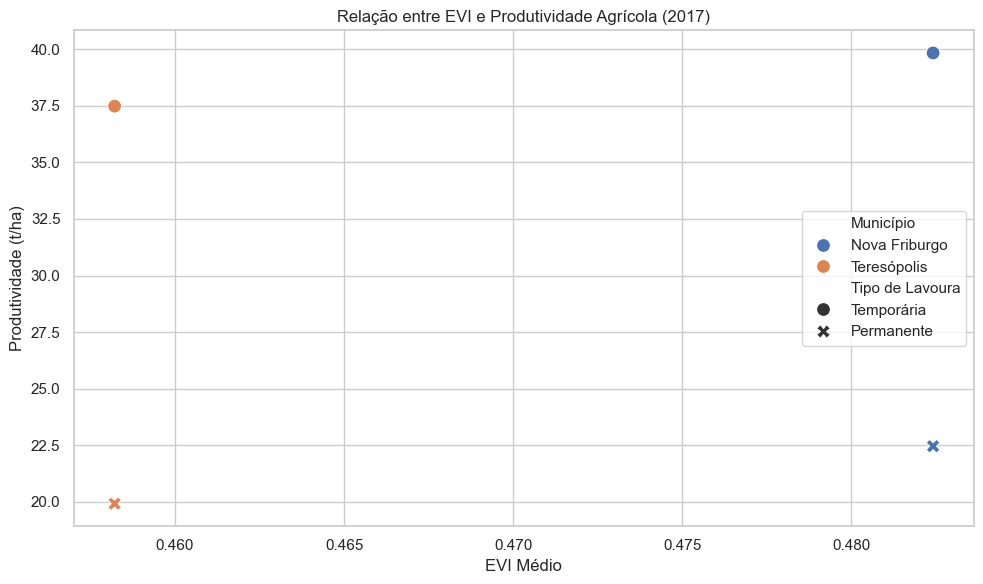

In [23]:
# Criar um gráfico de dispersão para visualizar a relação entre EVI e produtividade
plt.figure(figsize=(10, 6))
sns.scatterplot(x='EVI_mean', y='Produtividade (t/ha)', hue='Município', 
                style='Tipo de Lavoura', s=100, data=df_evi_prod)
plt.title('Relação entre EVI e Produtividade Agrícola (2017)')
plt.xlabel('EVI Médio')
plt.ylabel('Produtividade (t/ha)')
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. Exportar os Dados Pré-processados

Vamos exportar os dados pré-processados para serem utilizados no desenvolvimento do modelo de IA.

In [24]:
# Criar diretório para os dados pré-processados
os.makedirs('../../sprint2/assets', exist_ok=True)

# Exportar os dados de NDVI/EVI normalizados
df_ndvi_nf_monthly_scaled.to_csv('../../sprint2/assets/ndvi_mensal_nova_friburgo_preprocessado.csv', index=False)
df_ndvi_t_monthly_scaled.to_csv('../../sprint2/assets/ndvi_mensal_teresopolis_preprocessado.csv', index=False)

# Exportar os dados combinados de EVI e produtividade
df_evi_prod.to_csv('../../sprint2/assets/evi_produtividade_2017.csv', index=False)

print("Dados pré-processados exportados com sucesso!")

Dados pré-processados exportados com sucesso!


## Conclusão

Neste notebook, realizamos o pré-processamento dos dados de NDVI/EVI e produtividade agrícola para prepará-los para o desenvolvimento do modelo de IA. Realizamos as seguintes tarefas:

1. Carregamento dos dados de NDVI/EVI e produtividade agrícola
2. Limpeza e tratamento de valores ausentes
3. Normalização e padronização dos dados
4. Análise exploratória para identificar padrões e sazonalidades
5. Preparação dos dados para o modelo de IA
6. Exportação dos dados pré-processados

Os dados pré-processados estão prontos para serem utilizados no desenvolvimento do modelo de IA para previsão de produtividade agrícola, que será realizado no próximo notebook.